**Trabajo Práctico II: Predicción de lluvia en Australia**

Integrantes:

    Manuela Almada
    Elvio Di Prinzio
    Alfredo Sanz


Data set de entrada: weatherAUS.csv

Análisis descriptivo de las variables del dataset

Se describen las principales variables del dataset meteorológico australiano (weatherAUS.csv):

Date: Fecha de la observación meteorológica. Permite analizar tendencias temporales y estacionalidad.

Location: Nombre de la localidad donde se tomaron los datos. Es una variable categórica que identifica el punto geográfico.

MinTemp: Temperatura mínima registrada ese día (°C). Variable numérica, su rango depende de la zona y época del año.

MaxTemp: Temperatura máxima registrada ese día (°C). Variable numérica, útil para analizar extremos térmicos.

Rainfall: Precipitación acumulada (mm). Variable numérica, suele tener muchos ceros (días sin lluvia).

Evaporation: Agua evaporada (mm). Variable numérica, relacionada con temperatura y humedad.

Sunshine: Horas de sol. Variable numérica, indica la cantidad de radiación solar recibida.

WindGustDir: Dirección del viento en la ráfaga más fuerte. Variable categórica (N, NE, E, etc.).

WindGustSpeed: Velocidad de la ráfaga más fuerte (km/h). Variable numérica, muestra eventos extremos de viento.

WindDir9am / WindDir3pm: Dirección del viento a las 9am y 3pm. Variables categóricas.

WindSpeed9am / WindSpeed3pm: Velocidad del viento a las 9am y 3pm (km/h). Variables numéricas.

Humidity9am / Humidity3pm: Humedad relativa (%) a las 9am y 3pm. Variables numéricas, rango 0-100.

Pressure9am / Pressure3pm: Presión atmosférica (hPa) a las 9am y 3pm. Variables numéricas, rango típico 1000-1030 hPa.

Cloud9am / Cloud3pm: Cobertura de nubes (octas) a las 9am y 3pm. Variables numéricas, rango 0-8.

Temp9am / Temp3pm: Temperatura a las 9am y 3pm (°C). Variables numéricas.

RainToday: Indica si llovió ese día (Yes/No). Variable categórica binaria.

RainTomorrow: Variable objetivo, indica si lloverá al día siguiente (Yes/No).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import simplekml
from tqdm import tqdm

# Geo
from geopy.geocoders import Nominatim

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE

# Modelos
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc,
    roc_auc_score, r2_score, mean_absolute_error, ConfusionMatrixDisplay
)


# Configuración de visualización
plt.style.use('ggplot')
sns.set_palette('deep')


import optuna

import shap




### Acerca de las Localidades y de las Regiones:
Se encontró un archivo con las ciudades australianas y sus coordenadas en https://simplemaps.com/data/au-cities pero presentaba muchas diferencias de nombres con las localidades del data set weatherAUS.csv con lo cual se lo descartó como referencia de latitud y longitud. Posteriormente se consultaron a chatGPT cuales eran las latitudes y longitudes que correspondían a las 49 localidades que comprenden weatherAUS.csv incluyendo la fuente de información de donde se extrajo el dato. Este data set se denomina "localidades_australia_nuevo.csv" y es el que usamos finalmente para el trabajo.

In [ ]:
# ## 2. Carga y Fusión de Datos
# Datos meteorológicos
try:
    df_raw = pd.read_csv('weatherAUS.csv')
    print("Datos 'weatherAUS.csv' cargados.")
except FileNotFoundError:
    print("Error: No se encontró el archivo 'weatherAUS.csv'.")

# Datos de localidades (latitud/longitud)
try:
    df_localidades = pd.read_csv('localidades_australia_nuevo.csv')
    print("Datos 'localidades_australia_nuevo.csv' cargados.")
except FileNotFoundError:
    print("Error: No se encontró el archivo 'localidades_australia_nuevo.csv'.")

# Fusión entre df y df_cities usando Location y Localidad como claves
df_full = pd.merge(df_raw, df_localidades, left_on='Location', right_on='Localidad')
print("DataFrames fusionados.")


Datos 'weatherAUS.csv' cargados.
Datos 'localidades_australia_nuevo.csv' cargados.
DataFrames fusionados.


In [ ]:
# 3. Clustering Geográfico
# Agrupamos las localidades en 8 regiones geográficas usando KMeans
# basadonos en latitud y longitud.

# Columnas con coordenadas
X_coords = df_full[['Latitud', 'Longitud']].dropna()

# KMeans con 8 clusters (uno para cada región)
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
# Ajustamos solo sobre los datos no nulos
kmeans.fit(X_coords)

# Predecimos (o asignamos NaN si las coords eran nulas)
df_full['Cluster'] = np.nan
df_full.loc[X_coords.index, 'Cluster'] = kmeans.labels_

# Nombres oficiales de las regiones de Australia
nombres_regiones = [
    'New South Wales',
    'Victoria',
    'Queensland',
    'Western Australia',
    'South Australia',
    'Tasmania',
    'Australian Capital Territory',
    'Northern Territory'
]

# Obtener los centroides de cada cluster
centroides = kmeans.cluster_centers_

# Ordenamos los centroides de norte a sur (mayor a menor latitud en hemisferio sur)
orden_centroides = np.argsort(centroides[:,0])[::-1]
cluster_a_nombre = {orden_centroides[i]: nombres_regiones[i] for i in range(len(nombres_regiones))}

# Mapear los clusters a nombres reales
df_full['Region'] = df_full['Cluster'].map(cluster_a_nombre)

print("Variable 'Region' creada a partir de clustering:")
print(df_full['Region'].value_counts())

# Limpiar columnas temporales
df_full = df_full.drop(columns=['Cluster'])


Variable 'Region' creada a partir de clustering:
Region
South Australia                 52277
Northern Territory              30582
Tasmania                        21267
Australian Capital Territory    19847
Queensland                       7627
Victoria                         6080
New South Wales                  4771
Western Australia                3009
Name: count, dtype: int64


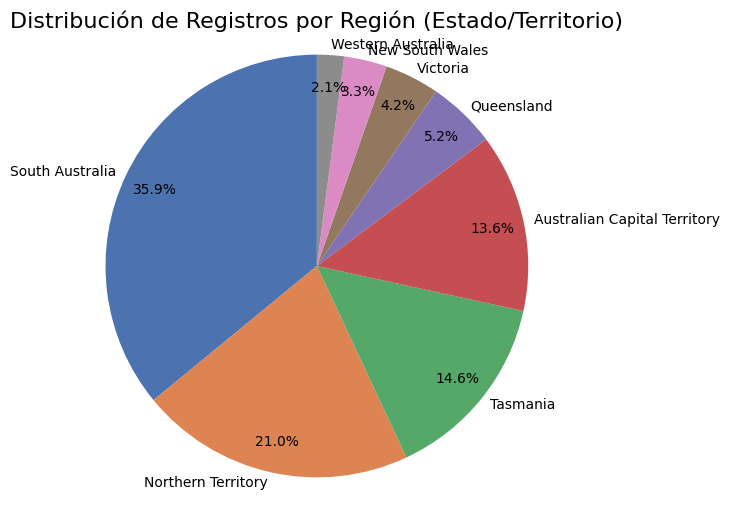

In [ ]:
# ¿Como está repartido el dataset entre las regiones?
data = {
    'South Australia': 52277,
    'Northern Territory': 30582,
    'Tasmania': 21267,
    'Australian Capital Territory': 19847,
    'Queensland': 7627,
    'Victoria': 6080,
    'New South Wales': 4771,
    'Western Australia': 3009
}

df_regions = pd.DataFrame(list(data.items()), columns=['Region', 'Count'])
df_regions = df_regions.sort_values(by='Count', ascending=False)

plt.figure(figsize=(6, 6))

plt.pie(
    df_regions['Count'],
    labels=df_regions['Region'],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    labeldistance=1.05
)

plt.axis('equal')

plt.title('Distribución de Registros por Región (Estado/Territorio)', fontsize=16)

plt.show()


### 4. Análisis Exploratorio de Datos (EDA)

In [ ]:
# ### 4.1 Información General y Faltantes
# Conteo de valores faltantes
print('\nValores faltantes por columnas (Antes de limpiar target):')
missing_values = df_full.isna().sum().sort_values(ascending=False)
print(missing_values)



Valores faltantes por columnas (Antes de limpiar target):
Sunshine         69835
Evaporation      62790
Cloud3pm         59358
Cloud9am         55888
Pressure9am      15065
Pressure3pm      15028
WindDir9am       10566
WindGustDir      10326
WindGustSpeed    10263
Humidity3pm       4507
WindDir3pm        4228
Temp3pm           3609
RainTomorrow      3267
RainToday         3261
Rainfall          3261
WindSpeed3pm      3062
Humidity9am       2654
Temp9am           1767
WindSpeed9am      1767
MinTemp           1485
MaxTemp           1261
Fuente               0
Latitud              0
Longitud             0
Date                 0
Localidad            0
Location             0
Region               0
dtype: int64


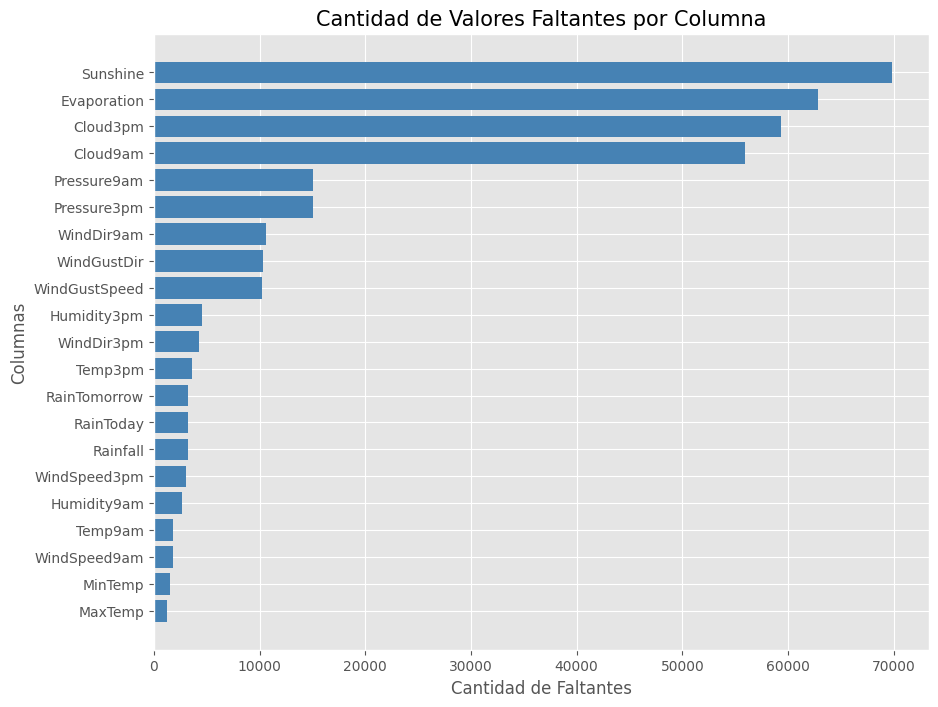

In [ ]:
# Graficamos los faltantes
missing_to_plot = missing_values[missing_values > 0]

plt.figure(figsize=(10, 8))
plt.barh(missing_to_plot.index, missing_to_plot.values, color='steelblue')

plt.title('Cantidad de Valores Faltantes por Columna', fontsize=15)
plt.xlabel('Cantidad de Faltantes', fontsize=12)
plt.ylabel('Columnas', fontsize=12)

plt.gca().invert_yaxis()
plt.show()


Se observa una fuerte desproporción de faltantes en función del atributo. Vamos a definir estrategias distintas para atenuar este tema en cada caso particular.

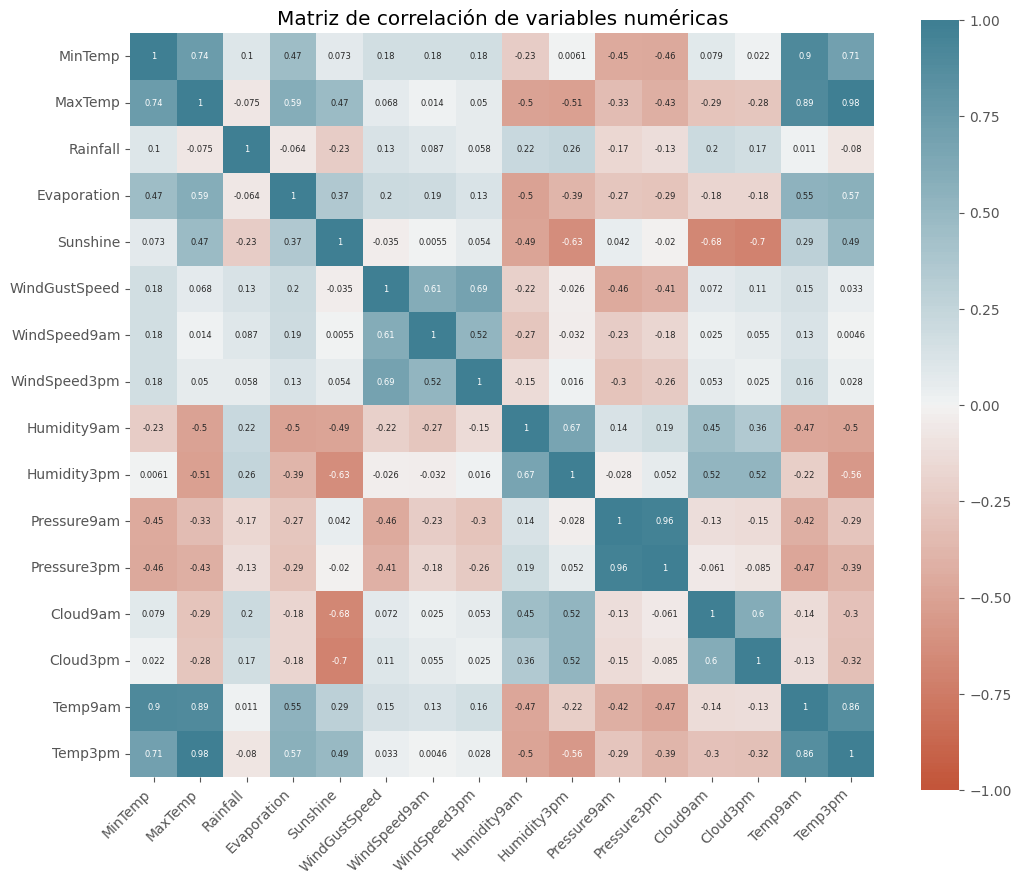

In [ ]:
# ### 4.2 ¿Qué nos dicen los Datos?

# Matriz de correlación
n_columns = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
             'Sunshine', 'WindGustSpeed', 'WindSpeed9am',
             'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
             'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
             'Temp3pm']

corr = df_full[n_columns].corr(method='pearson')
plt.figure(figsize=(12,10))
plt.title('Matriz de correlación de variables numéricas')
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.show()


In [ ]:
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['Variable1', 'Variable2', 'Correlation']

# Quitar duplicados y la diagonal (correlación consigo misma = 1)
corr_pairs = corr_pairs[corr_pairs['Variable1'] != corr_pairs['Variable2']]
corr_pairs = corr_pairs.drop_duplicates(subset=['Correlation'])

# Ordenar por el valor absoluto de la correlación (de mayor a menor)
corr_pairs = corr_pairs.reindex(corr_pairs['Correlation'].abs().sort_values(ascending=False).index)

print('Top 30 variables con mayor correlación')
print(corr_pairs.head(30))

Top 30 variables con mayor correlación
         Variable1     Variable2  Correlation
31         MaxTemp       Temp3pm     0.984503
171    Pressure9am   Pressure3pm     0.961326
14         MinTemp       Temp9am     0.901821
30         MaxTemp       Temp9am     0.887210
239        Temp9am       Temp3pm     0.860591
1          MinTemp       MaxTemp     0.736555
15         MinTemp       Temp3pm     0.708906
77        Sunshine      Cloud3pm    -0.703930
87   WindGustSpeed  WindSpeed3pm     0.686307
76        Sunshine      Cloud9am    -0.675323
137    Humidity9am   Humidity3pm     0.666949
73        Sunshine   Humidity3pm    -0.629130
86   WindGustSpeed  WindSpeed9am     0.605303
205       Cloud9am      Cloud3pm     0.603564
19         MaxTemp   Evaporation     0.587932
63     Evaporation       Temp3pm     0.572893
159    Humidity3pm       Temp3pm    -0.557841
62     Evaporation       Temp9am     0.545115
157    Humidity3pm      Cloud3pm     0.523120
103   WindSpeed9am  WindSpeed3pm     0.51

### Conclusiones del Heatmap
1. 🌡️ Fuerte Multicolinealidad entre Variables de Temperatura y Presión
Se observa una correlación positiva casi perfecta (valores muy cercanos a 1.0, en rojo brillante) entre varios pares de variables.

MaxTemp y Temp3pm (0.98): Son casi la misma variable. La temperatura máxima del día y la temperatura a las 3 PM son redundantes.

MinTemp y Temp9am (0.90): Similarmente, la temperatura mínima está fuertemente ligada a la temperatura de la mañana.

Pressure9am y Pressure3pm (0.96): La presión atmosférica a las 9 AM y a las 3 PM apenas cambia en términos relativos.

Para tener en cuenta:
Si mantenemos todos estos pares de variables en un modelo lineal (como la Regresión Logística) es problemático. Causa multicolinealidad, lo que infla la varianza de los coeficientes del modelo, haciéndolos inestables y difíciles de interpretar. Para el feature selection, deberíamos elegir solo una variable de cada par (ej. MaxTemp en lugar de Temp3pm).

2. ☁️ Correlaciones Negativas Lógicas (Validación de Coherencia)
Tenemos fuertes correlaciones negativas (valores cercanos a -1.0, en morado oscuro) que validan la coherencia de los datos.

Sunshine y Cloud3pm (-0.70): Esta es la correlación negativa más fuerte. Es lógicamente intuitivo: a mayor nubosidad (Cloud3pm), menor cantidad de horas de sol (Sunshine).

Sunshine y Cloud9am (-0.68): La misma lógica se aplica a la nubosidad matutina.

Sunshine y Humidity3pm (-0.63): Los días con alta humedad por la tarde (que suele preceder a la lluvia) tienden a ser menos soleados.

Esto podemos considerarlo como "una buena señal": las variables se comportan como se esperaría en el mundo real lo cual nos da confianza sobre la calidad del dataset.

3. 💧 Identificación de Predictores Clave para la Lluvia
Si observamos la fila/columna RainToday (sería el "proxy" de nuestro objetivo final, RainTomorrow), podemos identificar qué variables están más asociadas con la lluvia.

Correlación Positiva: Las variables con mayor correlación positiva (aunque moderada) con RainToday son Rainfall (0.50) (bastante obvio: si llueve, el rainfall es > 0), Humidity3pm (0.32), Cloud3pm (0.32) y Cloud9am (0.30).

Correlación Negativa: La variable con mayor correlación negativa es Sunshine (-0.33).

Esto es una indicación que permite anticipar que la humedad y la nubosidad (especialmente por la tarde) serán variables muy influyentes para predecir lluvia: alta humedad y alta nubosidad van a incrementan la probabilidad de lluvia.

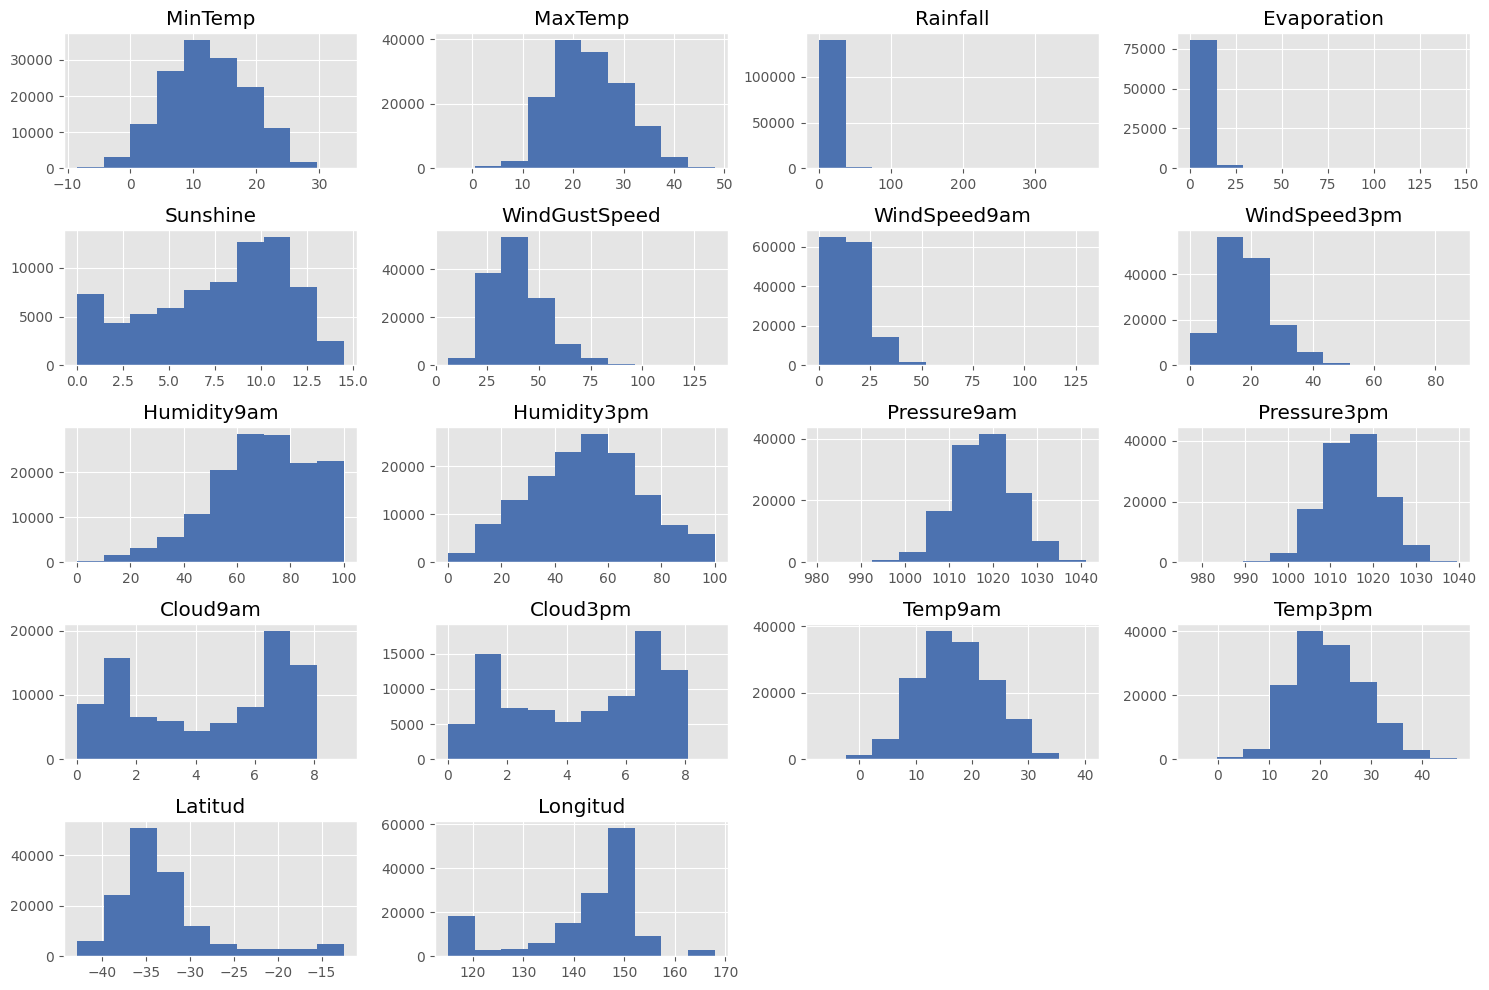

In [ ]:
df_full.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

### ¿Qué observamos en los histogramas?

1. 📈 Asimetría Dominante: la mayoría de las variables no siguen una distribución normal.

Sesgo a la Derecha: Las variables **Rainfall** y **Evaporation** están fuertemente sesgadas a la derecha. El eje Y esté en escala logarítmica (log=True) lo que confirma que la gran mayoría de los registros tienen valores de 0 o muy cercanos a 0, con muy pocos valores atípicos altos.

Las variables de viento (WindGustSpeed, WindSpeed9am, WindSpeed3pm) también muestran un sesgo a la derecha más moderado.

Sesgo a la Izquierda: Humidity9am está sesgada a la izquierda, indicando que es más común tener mañanas con humedad alta o muy alta.

2. 🔔 Variabilidad en las Distribuciones

Humidity3pm, Pressure9am y Pressure3pm: Estas son las variables más simétricas y parecidas a una campana (distribución normal). Son candidatas a predictoras importantes por su distribución centrada (variables estables).


3. ⚙️ ¿Cómo puede afectar ésto al Modelado?

Para Modelos Lineales (Ej. Regresión Logística): Estos modelos se verán muy afectados por la asimetría. Será necesario evaluar la aplicación de transformaciones de datos (como la transformación logarítmica o raíz cuadrada) para "normalizar" estas variables antes de entrenar el modelo.

Para Modelos Basados en Árboles (Ej. Random Forest): Estos modelos son robustos a la asimetría y a la escala de las variables. Probablemente manejarán bien estos datos "crudos" (o simplemente escalados) sin necesidad de transformaciones complejas para corregir el sesgo.

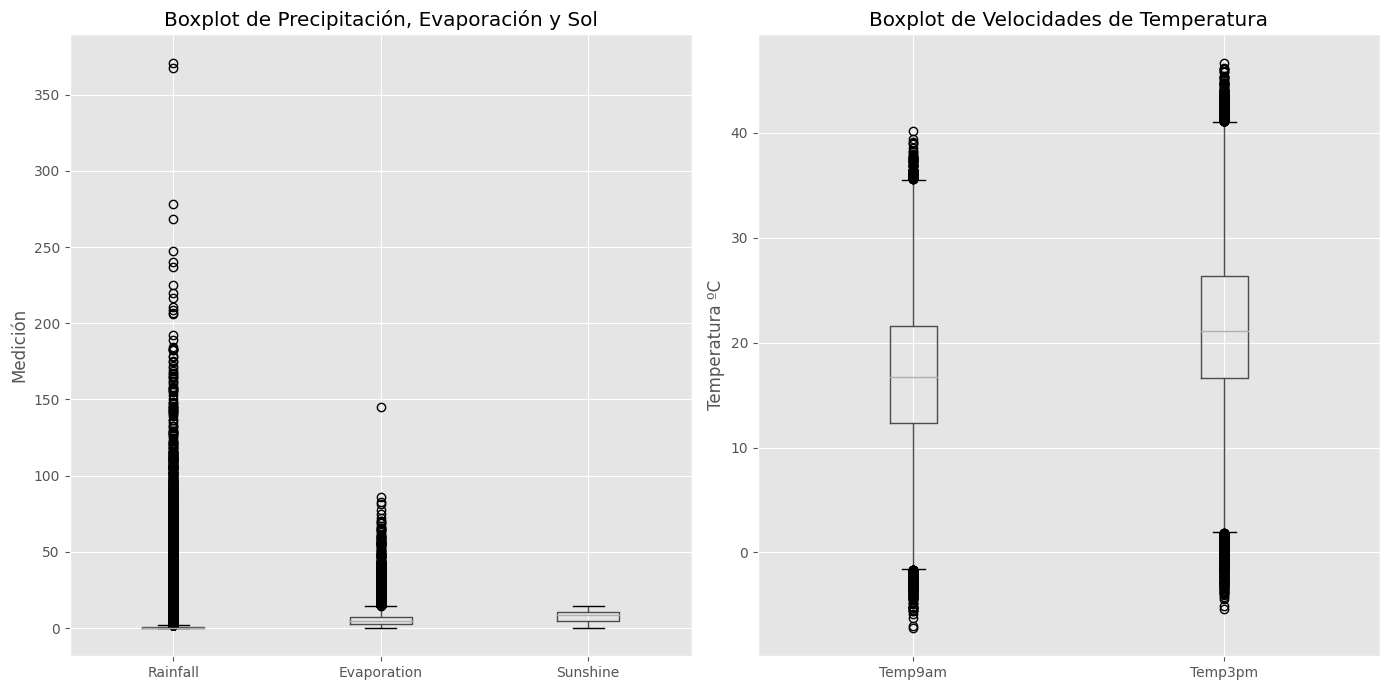

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))

df_full[['Rainfall', 'Evaporation', 'Sunshine']].boxplot(ax=axes[0])
axes[0].set_title('Boxplot de Precipitación, Evaporación y Sol')
axes[0].set_ylabel('Medición')

# ¡Aquí pones las variables para tu segundo gráfico!
# Como ejemplo, uso las variables de viento:
df_full[['Temp9am', 'Temp3pm']].boxplot(ax=axes[1])
axes[1].set_title('Boxplot de Velocidades de Temperatura')
axes[1].set_ylabel('Temperatura ºC') # Ajusta esta etiqueta

plt.tight_layout()
plt.show()

¿Qué obsrvamos en los boxplots?

Hay una clara distinción en la distribución y el comportamiento de las variables.

Rainfall y Evaporation presentan alta asimetría y la presencia de numerosos valores atípicos.

¿Que reflehja ésto de la realidad?
1) Que hay un número considerable de días con eventos de lluvia intensa.
2) Que la evaporación tiende a ser baja o moderada la mayoría de los días, con algunos picos.

Las variables de temperatura (Temp9am, Temp3pm) muestran distribuciones mucho más regulares y simétricas, con menos problemas de valores extremos, lo que las hace más "fáciles" de manejar en el proceso de modelado.

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


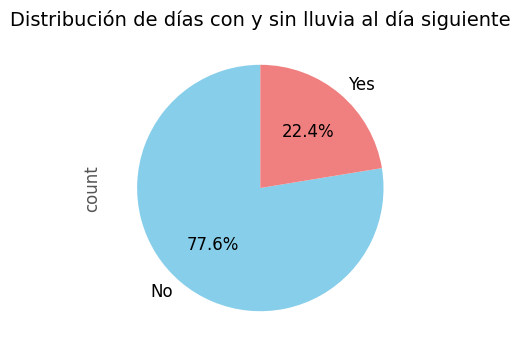

In [ ]:
# ### 4.3 Análisis de Desbalance de la Variable Target
df_full['RainTomorrow'] = df_full['RainTomorrow'].astype('category')
counts = df_full["RainTomorrow"].value_counts()
print(counts)

plt.figure(figsize=(4, 4))

counts.plot(
    kind='pie',
    colors=['skyblue', 'lightcoral'],
    autopct='%1.1f%%',  # Formato para mostrar porcentajes (ej. 77.8%)
    startangle=90,
    fontsize=12
)

plt.title("Distribución de días con y sin lluvia al día siguiente", fontsize=14)
plt.show()

Observamos en el gráfico que nuestro dataset presenta un **fuerte desbalance en la variable target** . Debemos prestar mucha atención a ésto: si el desbalance persiste al momento de entrenar el modelo, es muy probable que este tienda a predecir con mayor frecuencia la clase mayoritaria (en este caso, “No va a llover”).

Esto ocurre porque el modelo puede alcanzar una aparente "alta precisión" simplemente prediciendo siempre la clase dominante, pero a costa de un bajo desempeño en la detección de los días en que sí llueve, que justamente es lomás interesante de  un problema de predicción meteorológica.

### 5. Preparación de Datos
Tareas:
1. Vamos a eliminar filas donde la variable objetivo ('RainTomorrow') es nula.
2. Mapeamos la variable objetivo a valores binarios (0/1).
3. Separamos los datos en conjuntos de Entrenamiento y Prueba (Test).

In [ ]:
# ### 5.1 Limpieza Inicial y División de Datos
## Eliminamos filas con 'RainTomorrow' nulo
n_inicial = len(df_full)
df_processed = df_full.dropna(subset=['RainTomorrow'])
n_final = len(df_processed)
print(f"Se eliminaron {n_inicial - n_final} filas con RainTomorrow nulo.")


Se eliminaron 3267 filas con RainTomorrow nulo.


In [ ]:
# Mapeo de la variable objetivo
y = df_processed['RainTomorrow'].map({'Yes': 1, 'No': 0}).astype(int)

# Definición de X (features) excluyendo variables irrelevantes
columnas_excluir = [
    'Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
    'Localidad', 'Latitud', 'Longitud', 'Fuente', 'RainTomorrow'
]

X = df_processed.drop(columns=columnas_excluir).copy()

# División en entrenamiento y test (estratificada por 'y' por el desbalance que encontramos)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")

Tamaño de X_train: (113754, 18)
Tamaño de X_test: (28439, 18)


Aclaración Importante sobre Date.

Evidantemente no es lo mismo el clima en invierno que en verano. Es probable que el data set tenga modas asociadas a las estaciones. Para esto podríamos agrupar las fechas en cuatro variables (Winter, Spring, Autumm, Summer) para agregarlas al aálisis. Dejamos constancia de que reconocemos su importancia pero ya no disponemos de más tiempo físico para aborar un cambio tan profundo.

### 5.2 Ingeniería de Variables (Post-Split)

In [ ]:
# Aplicamos todas las codificacionjes (cíclica, categórica, etc.) por separado a train y test.

# 1. Viento: Codificación Cíclica
direccion_a_grados = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 'E': 90, 'ESE': 112.5,
    'SE': 135, 'SSE': 157.5, 'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}
wind_cols_original = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
wind_cols_new = ['wind_gust_x', 'wind_gust_y', 'wind_9am_x', 'wind_9am_y', 'wind_3pm_x', 'wind_3pm_y']

def encode_wind_direction(df_in, cols, mapping):
    df_out = df_in.copy()
    df_original_wind = df_processed.loc[df_in.index, cols]

    for col in cols:
        # Primero mapear a grados
        deg_col = df_original_wind[col].map(mapping)
        # Después convertir a radianes
        rad_col = np.deg2rad(deg_col)

        df_out[f'{col.replace("Dir", "")}_x'] = np.cos(rad_col)
        df_out[f'{col.replace("Dir", "")}_y'] = np.sin(rad_col)
    return df_out


X_train_featured = encode_wind_direction(X_train, wind_cols_original, direccion_a_grados)
X_test_featured = encode_wind_direction(X_test, wind_cols_original, direccion_a_grados)


In [ ]:
# 2. Nubes: Codificación Categórica
def clasificar_nubosidad(valor):
    if pd.isna(valor):
        return np.nan
    if valor <= 4: # Ajustado (0-4 octas = Bajo/Medio)
        return 'Bajo_Medio'
    else: # (5-8 octas = Alto)
        return 'Alto'

X_train_featured['Cloud9am_cat'] = X_train_featured['Cloud9am'].apply(clasificar_nubosidad)
X_train_featured['Cloud3pm_cat'] = X_train_featured['Cloud3pm'].apply(clasificar_nubosidad)
X_test_featured['Cloud9am_cat'] = X_test_featured['Cloud9am'].apply(clasificar_nubosidad)
X_test_featured['Cloud3pm_cat'] = X_test_featured['Cloud3pm'].apply(clasificar_nubosidad)


In [ ]:
# 3. RainToday, Region y Nubes_cat: Codificación One-Hot
categorical_cols = ['RainToday', 'Region', 'Cloud3pm_cat', 'Cloud9am_cat']

X_train_encoded = pd.get_dummies(X_train_featured, columns=categorical_cols, drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test_featured, columns=categorical_cols, drop_first=True, dtype=int)

# Alineamos las columnas (por si alguna categoría no apareció en el Test set)
X_train_final, X_test_final = X_train_encoded.align(X_test_encoded, join='inner', axis=1, fill_value=0)

print("Features después de ingeniería de variables y codificación:")
print(X_train_final.columns.tolist())


Features después de ingeniería de variables y codificación:
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'WindGust_x', 'WindGust_y', 'Wind9am_x', 'Wind9am_y', 'Wind3pm_x', 'Wind3pm_y', 'RainToday_Yes', 'Region_New South Wales', 'Region_Northern Territory', 'Region_Queensland', 'Region_South Australia', 'Region_Tasmania', 'Region_Victoria', 'Region_Western Australia', 'Cloud3pm_cat_Bajo_Medio', 'Cloud9am_cat_Bajo_Medio']


### 5.3 Escalado, Outliers e Imputación.

Tareas:
1. Escalar (preservando NaNs)
2. Reemplazar Outliers por NaNs
3. Imputar NaNs (usando múltiples estrategias: Mediana, KNN, RF)


In [ ]:
# Comenzamos por definimos las columnas numéricas que deben ser escaladas e imputadas
numeric_features = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed',
    'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
    'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm'
]
# Agregamos las features cíclicas (ya están entre -1 y 1, pero las incluimos por consistencia si KNN las usa)
numeric_features += wind_cols_new


In [ ]:
# --- 1. Escalado MinMax (Preservando NaNs) ---
def safe_scale_features(df, features, scaler):
    df_scaled = df.copy()
    # Asegurarnos que las features existen
    features_in_df = [f for f in features if f in df.columns]

    mask_notna_any = df[features_in_df].notna().any(axis=1)
    if mask_notna_any.sum() > 0:
        data_to_scale = df.loc[mask_notna_any, features_in_df]
        scaled_data = scaler.transform(data_to_scale)
        df_scaled.loc[mask_notna_any, features_in_df] = scaled_data
    return df_scaled

minmax_scaler = MinMaxScaler()

# Asegurarnos que las features existen en el df de train
features_for_scaling = [f for f in numeric_features if f in X_train_final.columns]

# Ajustar el escalador SOLO con datos limpios de entrenamiento (sin NaN)
train_clean_for_scaling = X_train_final[features_for_scaling].dropna()
print(f"Datos usados para ajustar escalador MinMax: {len(train_clean_for_scaling)} registros")
minmax_scaler.fit(train_clean_for_scaling)

# Aplicar escalado MinMax preservando NaN
X_train_scaled = safe_scale_features(X_train_final, features_for_scaling, minmax_scaler)
X_test_scaled = safe_scale_features(X_test_final, features_for_scaling, minmax_scaler)


Datos usados para ajustar escalador MinMax: 46466 registros


In [ ]:
# --- 2. Detección de Outliers y su reemplazo por NaN's ---
def detect_statistical_outliers(df, features, method='iqr'):
    df_no_outliers = df.copy()
    features_in_df = [f for f in features if f in df.columns]

    if method == 'iqr':
        for feature in features_in_df:
            if df_no_outliers[feature].notna().sum() > 0:
                Q1 = df_no_outliers[feature].quantile(0.25)
                Q3 = df_no_outliers[feature].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 3 * IQR
                upper_bound = Q3 + 3 * IQR
                outlier_mask = (df_no_outliers[feature] < lower_bound) | (df_no_outliers[feature] > upper_bound)
                df_no_outliers.loc[outlier_mask, feature] = np.nan
    elif method == 'isolation_forest':
        complete_data = df_no_outliers[features_in_df].dropna()
        if len(complete_data) > 100:
            iso_forest = IsolationForest(contamination=0.01, random_state=42)
            outlier_labels = iso_forest.fit_predict(complete_data)
            outlier_indices = complete_data.index[outlier_labels == -1]
            print(f"Se encontraron {len(outlier_indices)} outliers (IsolationForest) en {', '.join(features_in_df)}")
            for feature in tqdm(features_in_df, desc="Reemplazando outliers"):
                df_no_outliers.loc[outlier_indices, feature] = np.nan
    return df_no_outliers

iqr_features = ['MaxTemp', 'MinTemp', 'Temp9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp3pm']
iso_features = [c for c in features_for_scaling if c not in iqr_features]

print("Detectando outliers (IQR/IsolationForest) en X_train...")
X_train_no_outliers = detect_statistical_outliers(X_train_scaled, iqr_features, method='iqr')
X_train_no_outliers = detect_statistical_outliers(X_train_no_outliers, iso_features, method='isolation_forest')

print("Detectando outliers (IQR/IsolationForest) en X_test...")
X_test_no_outliers = detect_statistical_outliers(X_test_scaled, iqr_features, method='iqr')
X_test_no_outliers = detect_statistical_outliers(X_test_no_outliers, iso_features, method='isolation_forest')


Detectando outliers (IQR/IsolationForest) en X_train...
Se encontraron 466 outliers (IsolationForest) en Rainfall, Evaporation, Sunshine, WindGustSpeed, WindSpeed9am, WindSpeed3pm, Humidity9am, Cloud9am, Cloud3pm


Reemplazando outliers: 100%|██████████| 9/9 [00:00<00:00, 1833.44it/s]

Detectando outliers (IQR/IsolationForest) en X_test...


Se encontraron 117 outliers (IsolationForest) en Rainfall, Evaporation, Sunshine, WindGustSpeed, WindSpeed9am, WindSpeed3pm, Humidity9am, Cloud9am, Cloud3pm


Reemplazando outliers: 100%|██████████| 9/9 [00:00<00:00, 2250.83it/s]


In [ ]:
# --- 3. Imputación de Faltantes en etapas Múltiples ---

def calculate_missing_percentage(df, columns):
    missing_data_list = []
    columns_in_df = [c for c in columns if c in df.columns]
    for col in columns_in_df:
        missing_percentage = (df[col].isna().sum() * 100 / len(df)).round(2)
        missing_data_list.append({'Columna': col, 'Porcentaje_Faltante': missing_percentage})
    return pd.DataFrame(missing_data_list).sort_values(by='Porcentaje_Faltante', ascending=False)

missing_train_df = calculate_missing_percentage(X_train_no_outliers, features_for_scaling)
print("\nPorcentaje de faltantes (Train) antes de imputar:")
print(missing_train_df.head(10))


Porcentaje de faltantes (Train) antes de imputar:
          Columna  Porcentaje_Faltante
4        Sunshine                48.18
3     Evaporation                43.22
13       Cloud3pm                40.56
12       Cloud9am                38.10
10    Pressure9am                 9.93
11    Pressure3pm                 9.91
5   WindGustSpeed                 6.95
9     Humidity3pm                 2.55
7    WindSpeed3pm                 2.28
15        Temp3pm                 1.94


In [ ]:
# Variables para imputar por mediana: FALTANTES <= 1%
median_cols_to_impute = missing_train_df[missing_train_df['Porcentaje_Faltante'] <= 1.0]['Columna'].tolist()
print(f"\nColumnas a imputar por Mediana: {median_cols_to_impute}")
if median_cols_to_impute:
    imputer_median = SimpleImputer(strategy='median')
    X_train_no_outliers[median_cols_to_impute] = imputer_median.fit_transform(X_train_no_outliers[median_cols_to_impute])
    X_test_no_outliers[median_cols_to_impute] = imputer_median.transform(X_test_no_outliers[median_cols_to_impute])



Columnas a imputar por Mediana: ['Temp9am', 'MinTemp', 'MaxTemp']


In [ ]:
# Variables para imputar por KNN: 1% < FALTANTES < 10%
knn_cols_to_impute = missing_train_df[
    (missing_train_df['Porcentaje_Faltante'] > 1.0) & (missing_train_df['Porcentaje_Faltante'] <= 10.0)
]['Columna'].tolist()
print(f"\nColumnas a imputar por KNN: {knn_cols_to_impute}")
if knn_cols_to_impute:
    knn_imputer = KNNImputer(n_neighbors=5)
    X_train_no_outliers[knn_cols_to_impute] = knn_imputer.fit_transform(X_train_no_outliers[knn_cols_to_impute])
    X_test_no_outliers[knn_cols_to_impute] = knn_imputer.transform(X_test_no_outliers[knn_cols_to_impute])



Columnas a imputar por KNN: ['Pressure9am', 'Pressure3pm', 'WindGustSpeed', 'Humidity3pm', 'WindSpeed3pm', 'Temp3pm', 'Humidity9am', 'Rainfall', 'WindSpeed9am']


In [ ]:
# Variables para imputar por RF Regressor: FALTANTES > 10%
rf_cols_to_impute = missing_train_df[missing_train_df['Porcentaje_Faltante'] > 10.0]['Columna'].tolist()
print(f"\nColumnas a imputar por RF: {rf_cols_to_impute}")

X_train_imputed = X_train_no_outliers.copy()
X_test_imputed = X_test_no_outliers.copy()

# Definimos las features que usará el RF Imputer
base_features_for_rf = [c for c in X_train_imputed.columns if c not in rf_cols_to_impute and c in features_for_scaling]

for target_col in tqdm(rf_cols_to_impute, desc="Imputando (RF)"):
    # Features para el modelo (usamos solo las features base + las ya imputadas de RF)
    features_rf = base_features_for_rf + [c for c in rf_cols_to_impute if c != target_col and c in X_train_imputed.columns]

    # Datos para entrenar el RF (donde el target NO es nulo)
    train_rf = X_train_imputed[X_train_imputed[target_col].notnull()]
    # Datos para predecir (donde el target ES nulo)
    predict_rf_train = X_train_imputed[X_train_imputed[target_col].isnull()]
    predict_rf_test = X_test_imputed[X_test_imputed[target_col].isnull()]

    # Entrenamos el RF Regressor
    if not train_rf.empty:
        rf_imputer = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
        rf_imputer.fit(train_rf[features_rf], train_rf[target_col])

        # Imputamos
        if not predict_rf_train.empty:
            X_train_imputed.loc[X_train_imputed[target_col].isnull(), target_col] = rf_imputer.predict(predict_rf_train[features_rf])
        if not predict_rf_test.empty:
            X_test_imputed.loc[X_test_imputed[target_col].isnull(), target_col] = rf_imputer.predict(predict_rf_test[features_rf])

print("\nVerificación de NaNs en X_train (numéricas):")
print(X_train_imputed[features_for_scaling].isna().sum().sum())
print("Verificación de NaNs en X_test (numéricas):")
print(X_test_imputed[features_for_scaling].isna().sum().sum())

# Asignamos los dataframes finales
X_train_final = X_train_imputed
X_test_final = X_test_imputed



Columnas a imputar por RF: ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']


Imputando (RF): 100%|██████████| 4/4 [00:31<00:00,  7.94s/it]


Verificación de NaNs en X_train (numéricas):
0
Verificación de NaNs en X_test (numéricas):
0


### 5.4 Balanceo de Clases con SMOTE

In [ ]:
# Aplicamos SMOTE solo al conjunto de entrenamiento.

print("\n[5.4] Aplicando SMOTE para balancear el conjunto de entrenamiento...")
smote = SMOTE(random_state=42)

# Asegurarnos que no haya NaNs
X_train_final_filled = X_train_final.fillna(X_train_final.median())
X_test_final_filled = X_test_final.fillna(X_train_final.median()) # Usamos la mediana de train por si acaso

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final_filled, y_train)

print("Distribución de clases después de SMOTE:")
print(y_train_resampled.value_counts())



[5.4] Aplicando SMOTE para balancear el conjunto de entrenamiento...
Distribución de clases después de SMOTE:
RainTomorrow
0    88252
1    88252
Name: count, dtype: int64


## 6. Modelado

In [ ]:
# Función auxiliar para graficar ROC
def plot_roc_curve(model, X_test, y_test, name):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--') # Línea de azar
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Curva ROC - {name}')
    plt.legend(loc="lower right")




--- 6.1 Modelo Base (Dummy) ---
              precision    recall  f1-score   support

           0       0.78      0.50      0.61     22064
           1       0.22      0.50      0.31      6375

    accuracy                           0.50     28439
   macro avg       0.50      0.50      0.46     28439
weighted avg       0.65      0.50      0.54     28439



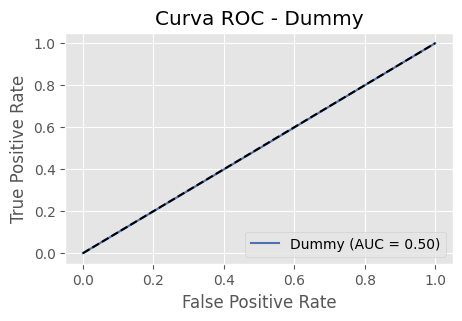

<Figure size 200x200 with 0 Axes>

In [ ]:
# ### 6.1 Modelo Base (Dummy Classifier)
print("\n--- 6.1 Modelo Base (Dummy) ---")
dummy_clf = DummyClassifier(strategy="stratified", random_state=42)
dummy_clf.fit(X_train_resampled, y_train_resampled)
y_pred_dummy = dummy_clf.predict(X_test_final_filled)
print(classification_report(y_test, y_pred_dummy))
plt.figure(figsize=(5, 3))
plot_roc_curve(dummy_clf, X_test_final_filled, y_test, name="Dummy")


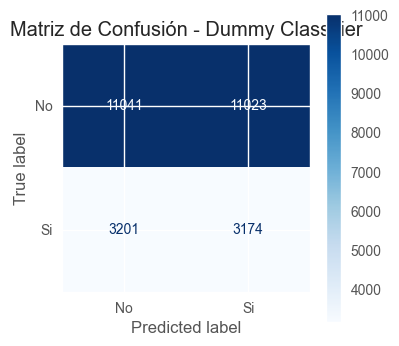

In [ ]:
# Matriz de Confusión del Dummy Classifier


fig, ax = plt.subplots(figsize=(4, 4))

# Usamos .from_estimator para que calcule y grafique todo automáticamente
ConfusionMatrixDisplay.from_estimator(
    dummy_clf,                  # El modelo entrenado
    X_test_final_filled,        # Los datos de prueba (features)
    y_test,                     # Las etiquetas reales
    display_labels=['No', 'Si'],# (Opcional) Nombres personalizados para las clases
    cmap=plt.cm.Blues,          # Color del mapa
    values_format='d',          # Formato de enteros ('d' = decimal integer)
    ax=ax                       # Le pasamos el eje que creamos arriba
)

ax.set_title("Matriz de Confusión - Dummy Classifier")
plt.show()


--- 6.2 Regresión Logística ---
              precision    recall  f1-score   support

           0       0.92      0.79      0.85     22064
           1       0.52      0.77      0.62      6375

    accuracy                           0.79     28439
   macro avg       0.72      0.78      0.74     28439
weighted avg       0.83      0.79      0.80     28439



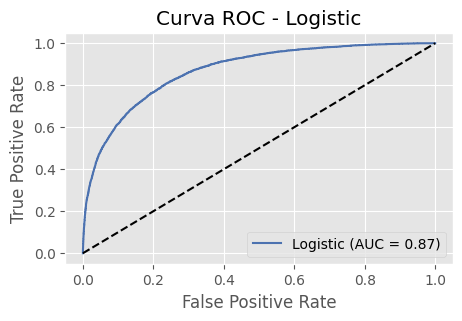

<Figure size 200x200 with 0 Axes>

In [ ]:
# ### 6.2 Regresión Logística
print("\n--- 6.2 Regresión Logística ---")
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train_resampled, y_train_resampled)
y_pred_lr = logistic_model.predict(X_test_final_filled)
print(classification_report(y_test, y_pred_lr))
plt.figure(figsize=(5, 3))
plot_roc_curve(logistic_model, X_test_final_filled, y_test, name="Logistic")


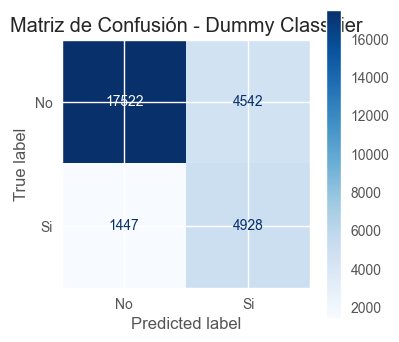

In [ ]:
# Matriz de Confusión de Regresión Logística

fig, ax = plt.subplots(figsize=(4, 4))

# Usamos .from_estimator para que calcule y grafique todo automáticamente
ConfusionMatrixDisplay.from_estimator(
    logistic_model,                  # El modelo entrenado
    X_test_final_filled,        # Los datos de prueba (features)
    y_test,                     # Las etiquetas reales
    display_labels=['No', 'Si'],# (Opcional) Nombres personalizados para las clases
    cmap=plt.cm.Blues,          # Color del mapa
    values_format='d',          # Formato de enteros ('d' = decimal integer)
    ax=ax                       # Le pasamos el eje que creamos arriba
)

ax.set_title("Matriz de Confusión - Dummy Classifier")
plt.show()


--- 6.3 Random Forest ---
              precision    recall  f1-score   support

           0       0.90      0.89      0.90     22064
           1       0.64      0.67      0.66      6375

    accuracy                           0.84     28439
   macro avg       0.77      0.78      0.78     28439
weighted avg       0.85      0.84      0.84     28439



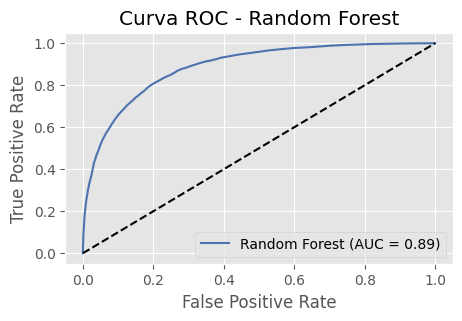

<Figure size 200x200 with 0 Axes>

In [ ]:
# ### 6.3 Random Forest
print("\n--- 6.3 Random Forest ---")
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test_final_filled)
print(classification_report(y_test, y_pred_rf))
plt.figure(figsize=(5, 3))
plot_roc_curve(rf_model, X_test_final_filled, y_test, name="Random Forest")

plt.show()


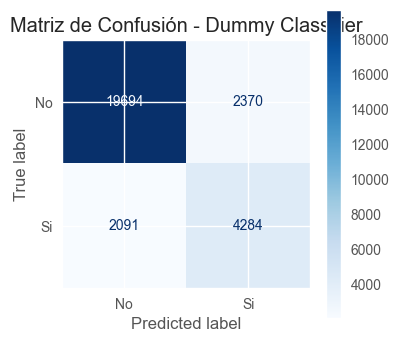

In [ ]:
# Matriz de Confusión de Random Forest

fig, ax = plt.subplots(figsize=(4, 4))

# Usamos .from_estimator para que calcule y grafique todo automáticamente
ConfusionMatrixDisplay.from_estimator(
    rf_model,                  # El modelo entrenado
    X_test_final_filled,        # Los datos de prueba (features)
    y_test,                     # Las etiquetas reales
    display_labels=['No', 'Si'],# (Opcional) Nombres personalizados para las clases
    cmap=plt.cm.Blues,          # Color del mapa
    values_format='d',          # Formato de enteros ('d' = decimal integer)
    ax=ax                       # Le pasamos el eje que creamos arriba
)

ax.set_title("Matriz de Confusión - Dummy Classifier")
plt.show()

### 7. Optimización de Hiperparámetros


--- 7. Optimización (Grid Search) ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Mejores parámetros encontrados:
{'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 150}

Reporte de Clasificación (Random Forest Optimizado):
              precision    recall  f1-score   support

           0       0.91      0.87      0.89     22064
           1       0.62      0.70      0.66      6375

    accuracy                           0.84     28439
   macro avg       0.76      0.79      0.77     28439
weighted avg       0.84      0.84      0.84     28439

[[19254  2810]
 [ 1881  4494]]


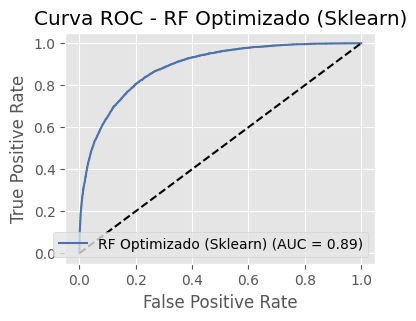

<Figure size 500x300 with 0 Axes>

In [ ]:
# Optimizamos el Random Forest usando GridSearchCV.

print("\n--- 7. Optimización (Grid Search) ---")
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20],
    'min_samples_leaf': [5, 10]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_resampled, y_train_resampled)

print("\nMejores parámetros encontrados:")
print(grid_search.best_params_)

# Evaluación del mejor modelo
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_final_filled)

print("\nReporte de Clasificación (Random Forest Optimizado):")
print(classification_report(y_test, y_pred_best_rf))
print(confusion_matrix(y_test, y_pred_best_rf))

plt.figure(figsize=(4, 3))
plot_roc_curve(best_rf, X_test_final_filled, y_test, name="RF Optimizado (Sklearn)")
plt.show()


### Optimización con Optuna

Para optimizar los hiperparámetros de nuestro modelo de regresión logística vamos a utilizar Optuna. Dado el tamaño de nuestro dataset, consideramos que una búsqueda exhaustiva con GridSearch podía implicar un costo computacional elevado, mientras que un RandomSearch podría dejar zonas relevantes del espacio de búsqueda sin explorar.

Los hiperparámetros a evaluar son:

C: inverso de la fuerza de regularización, controla cuánto penalizamos coeficientes grandes. Valores bajos implican mayor regularización y menor riesgo de sobreajuste.

penalty: tipo de regularización aplicada (L1 o L2).

solver: algoritmo de optimización; seleccionamos saga porque soporta ambos tipos de regularización y es eficiente para datasets grandes y dispersos.

max_iter: cantidad máxima de iteraciones para asegurar la convergencia del modelo.

Para seleccionar la mejor configuración se utyiliza como métrica el F1-score, ya que combina precisión + recall, permitiendo evaluar un balance adecuado entre ambas.


In [ ]:
def objective(trial, X, y):
    """
    Función objetivo que Optuna intentará optimizar.
    """

    # 1. Definir el espacio de búsqueda (Sampling)
    params = {
        'C': trial.suggest_categorical('C', [0.01, 0.1, 1, 10, 100]),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver': 'saga',
        'max_iter': 5000
    }
        # 2. Crear el modelo con los parámetros del trial
    model = LogisticRegression(**params, random_state=42)

    # 3. Evaluar el modelo usando Cross-Validation
    try:
        score = cross_val_score(model, X, y, cv=3, scoring='f1_macro', n_jobs=-1).mean()

    except ValueError as e:
        print(f"Trial fallido: {e}")
        return 0.0 # Un F1-score de 0 es el peor

    return score

In [ ]:
#  MAXIMIZAR el F1-score --> usamos direction='maximize'
study = optuna.create_study(direction='maximize')

study.optimize(lambda trial: objective(trial, X_train_resampled, y_train_resampled), n_trials=30)

best_optuna_params = study.best_params
print(f"Mejor valor (F1-score en CV): {study.best_value:.4f}")
print(f"Mejores hiperparámetros: {best_optuna_params}")

# 4. Entrenar el modelo final con los mejores parámetros
final_params = best_optuna_params.copy()
final_params['solver'] = 'saga'
final_params['max_iter'] = 5000

best_optuna_model = LogisticRegression(**final_params, random_state=42)
best_optuna_model.fit(X_train_resampled, y_train_resampled)

# 5. Evaluar en el conjunto de TEST

# y_pred = best_optuna_model.predict(X_test_prueba)
y_pred = best_optuna_model.predict(X_test_final_filled)

print("\n--- Reporte de Clasificación en Test (Modelo Optimizado) ---")
print(classification_report(y_test, y_pred))

[I 2025-11-07 11:37:55,134] A new study created in memory with name: no-name-71a9386c-41ca-4734-9ef6-7b9dfb0bcc4c
[I 2025-11-07 11:37:59,358] Trial 0 finished with value: 0.7904572859424964 and parameters: {'C': 100, 'penalty': 'l2'}. Best is trial 0 with value: 0.7904572859424964.
[I 2025-11-07 11:38:02,887] Trial 1 finished with value: 0.7900833477493485 and parameters: {'C': 0.1, 'penalty': 'l1'}. Best is trial 0 with value: 0.7904572859424964.
[I 2025-11-07 11:38:06,601] Trial 2 finished with value: 0.7904630381275887 and parameters: {'C': 10, 'penalty': 'l1'}. Best is trial 2 with value: 0.7904630381275887.
[I 2025-11-07 11:38:09,100] Trial 3 finished with value: 0.7904572859424964 and parameters: {'C': 100, 'penalty': 'l2'}. Best is trial 2 with value: 0.7904630381275887.
[I 2025-11-07 11:38:12,254] Trial 4 finished with value: 0.786224441459756 and parameters: {'C': 0.01, 'penalty': 'l1'}. Best is trial 2 with value: 0.7904630381275887.
[I 2025-11-07 11:38:15,046] Trial 5 finish

Mejor valor (F1-score en CV): 0.7905
Mejores hiperparámetros: {'C': 100, 'penalty': 'l1'}

--- Reporte de Clasificación en Test (Modelo Optimizado) ---
              precision    recall  f1-score   support

           0       0.92      0.79      0.85     22064
           1       0.52      0.77      0.62      6375

    accuracy                           0.79     28439
   macro avg       0.72      0.78      0.74     28439
weighted avg       0.83      0.79      0.80     28439




Tras la optimización, no se observan mejoras significativas respecto al modelo base. Esto puede deberse a que la regresión logística no estaba subajustada ni sobreajustada inicialmente, o a que los valores óptimos de los hiperparámetros se encontraban muy próximos a los ya utilizados en el modelo sin optimización. También es posible que el dataset tenga una estructura relativamente lineal, lo que hace que la regresión logística alcance su máximo rendimiento sin necesidad de ajustes complejos.

En síntesis, la optimización confirmó que el modelo ya se encontraba en una configuración adecuada, funcionando cerca de su rendimiento óptimo.

SHAP

In [ ]:
explainer = shap.Explainer(
    best_optuna_model, X_train_resampled,
    feature_names=X_train_resampled.columns.tolist()
)
#shap_values = explainer(X_test_prueba)
shap_values = explainer(X_test_final_filled)

In [ ]:
explainer.expected_value

0.2418726365354682


[4.1] Generando Summary Plot (Barra) - FINAL...


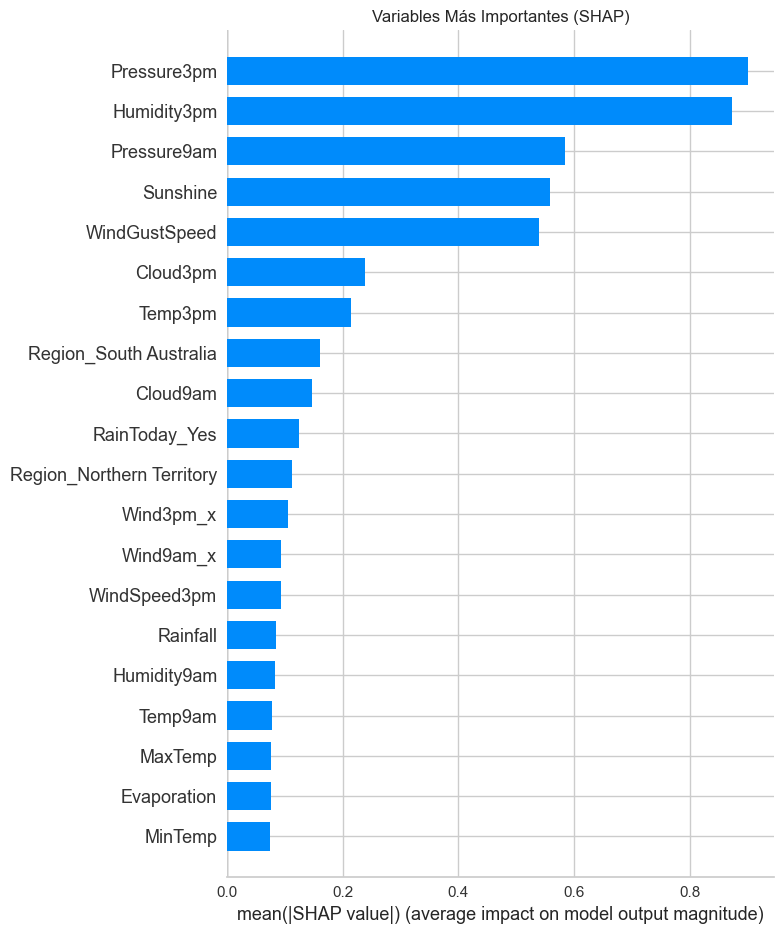

In [ ]:
# --- 3. Generación de Gráficas ---
print("\n[4.1] Generando Summary Plot (Barra) - FINAL...")
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test_final_filled.values,
    feature_names=X_train_resampled.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("Variables Más Importantes (SHAP)")
plt.tight_layout()
plt.show()

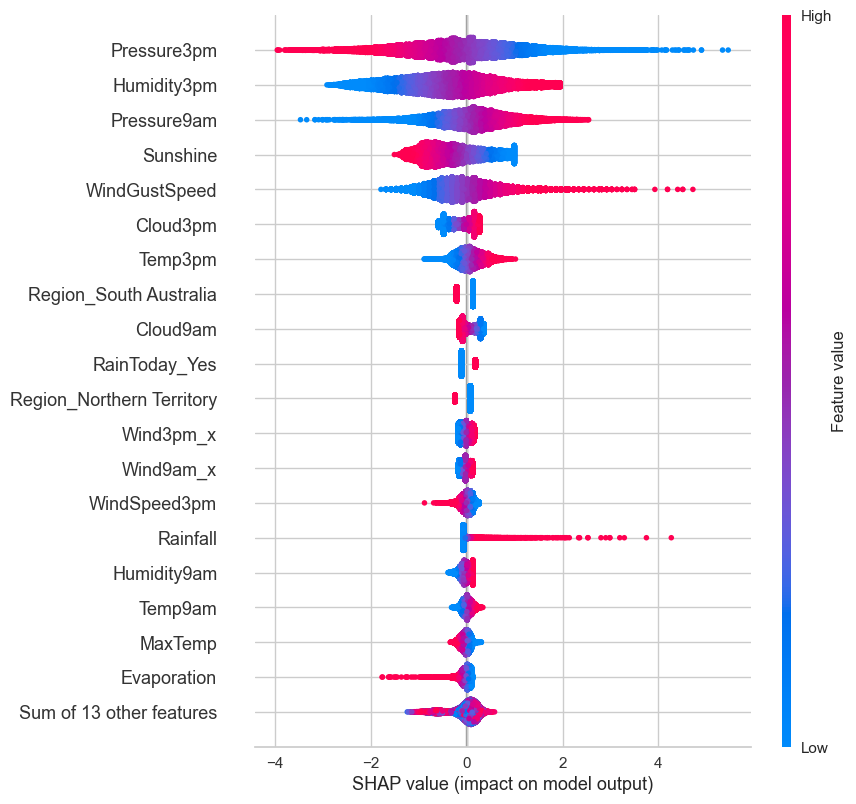

In [ ]:
shap.plots.beeswarm(shap_values, max_display=20)

In [ ]:
ind = 1
shap.initjs()
shap.plots.force(shap_values[ind], matplotlib=False)

A partir del análisis SHAP para la explicabilidad del modelo, observamos que la variables que aportan mayor poder explicativo son Pressure3pm y Humidity3pm, mientras que otras como wind_gust_y o wind_9am_y muestran un aporte individual menor. Esto puede deberse a que su efecto es conjunto, actuando en combinación con sus respectivas coordenadas x.

Al analizar el gráfico beeswarm de valores SHAP, se observa que:

. Baja presión atmosférica, alta humedad a las 3 p.m. y poca luz solar tienden a empujar al modelo a predecir que lloverá al día siguiente.

. Alta presión atmosférica, baja humedad y mayor cantidad de luz solar conducen a predicciones negativas (no lloverá).

En el force plot, se aprecia cómo determinadas variables incrementan o reducen la probabilidad de lluvia:

Humidity3pm es la más influyente; valores altos (por ejemplo, 0.74) aumentan significativamente la probabilidad de lluvia.

Sunshine, con valores bajos (por ejemplo, 0.16), también eleva la probabilidad de lluvia, indicando una relación inversa entre horas de sol y precipitación.

Por el contrario, temperaturas bajas a las 3 p.m. (por ejemplo, 0.25) disminuyen esta probabilidad.

En síntesis, el análisis SHAP nos permite entender el rol individual y conjunto de las variables sobre las predicciones del modelo. Este enfoque podría extenderse al resto de las variables, siguiendo la misma lógica de interpretación para identificar patrones consistentes en la relación entre las condiciones meteorológicas y la probabilidad de lluvia.



## AutoML con Pycaret

In [ ]:
from pycaret.classification import *

print("\n" + "="*70)
print("SECCIÓN 7: MODELADO AUTOMATIZADO CON PYCARET (FINAL)")
print("="*70)

# 1. Preparación del DataFrame
df_pycaret_train = pd.concat([X_train, y_train], axis=1)
categorical_features_pycaret = ['RainToday', 'Region']

# 2. Configuración del Entorno PyCaret
print("\n[7.1] Configurando el entorno PyCaret (Rápido)...")

clf1 = setup(
    data=df_pycaret_train,
    target='RainTomorrow',
    session_id=42,
    normalize=True,
    fix_imbalance=True,
    imputation_type='iterative',
    # Usamos la lista de categóricas ajustada
    categorical_features=categorical_features_pycaret,
    # Ignoramos las features que sabemos que fueron eliminadas o son componentes de viento
    ignore_features=['WindGustDir', 'WindDir9am', 'WindDir3pm', 'Location',
                     'wind_gust_x', 'wind_gust_y', 'wind_9am_x', 'wind_9am_y', 'wind_3pm_x', 'wind_3pm_y'],
    fold=3,
    verbose=False
)
print("✅ Configuración de PyCaret finalizada.")

# 3. Comparación de Modelos
print("\n[7.2] Comparando los 3 modelos más rápidos por AUC...")
best_models = compare_models(
    fold=3,
    sort='AUC',
    n_select=3,
    exclude=['knn', 'svm', 'rbfsvm', 'ridge', 'xgboost', 'lightgbm', 'gbc'],
    verbose=True
)
print("✅ Comparación de modelos finalizada.")

# 4. Ajustar y Optimizar el Mejor Modelo (Tuning Rápido)
print("\n[7.3] Optimizando el mejor modelo encontrado (Tuning Rápido)...")
tuned_model = tune_model(best_models[0], fold=3, optimize='AUC', choose_better=True, n_iter=10, verbose=False)
print(f"✅ Mejor modelo tuneado: {tuned_model.__class__.__name__}")

# 5. Evaluación Final
final_model = finalize_model(tuned_model)
X_test_with_target = pd.concat([X_test, y_test], axis=1)
predictions = predict_model(final_model, data=X_test_with_target)

from sklearn.metrics import roc_auc_score
print(f"\nROC-AUC en el set de prueba final: {roc_auc_score(predictions['RainTomorrow'], predictions['prediction_score']):.4f}")
print("✅ Sección 7 (PyCaret) completada.")


SECCIÓN 7: MODELADO AUTOMATIZADO CON PYCARET (FINAL)

[7.1] Configurando el entorno PyCaret (Rápido)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002620 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2320
[LightGBM] [Info] Number of data points in the train set: 79448, number of used features: 17
[LightGBM] [Info] Start training from score 23.234245
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2320
[LightGBM] [Info] Number of data points in the train set: 79269, number of used features: 17
[LightGBM] [Info] Start training from score 12.185562
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005694 seconds.
You can set `force_col_wise=true` to remo

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8512,0.8808,0.5921,0.6983,0.6408,0.5478,0.5508,102.0000
rf,Random Forest Classifier,0.8479,0.8796,0.6116,0.6784,0.6433,0.5470,0.5481,99.9800
lr,Logistic Regression,0.7900,0.8660,0.7720,0.5214,0.6225,0.4845,0.5024,83.0367
lda,Linear Discriminant Analysis,0.7913,0.8647,0.7647,0.5236,0.6216,0.4844,0.5009,97.2900
ada,Ada Boost Classifier,0.8103,0.8527,0.6730,0.5646,0.6140,0.4896,0.4929,101.5200
qda,Quadratic Discriminant Analysis,0.7615,0.8276,0.7481,0.4823,0.5852,0.4293,0.4506,102.1933
nb,Naive Bayes,0.7406,0.8234,0.7664,0.4535,0.5698,0.4011,0.4294,92.7133
dt,Decision Tree Classifier,0.7741,0.7017,0.5706,0.4967,0.5311,0.3832,0.3849,89.1867
dummy,Dummy Classifier,0.7758,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,95.2100


✅ Comparación de modelos finalizada.

[7.3] Optimizando el mejor modelo encontrado (Tuning Rápido)...
✅ Mejor modelo tuneado: ExtraTreesClassifier


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8545,0.8862,0.5983,0.7075,0.6483,0.5574,0.5605



ROC-AUC en el set de prueba final: 0.2932
✅ Sección 7 (PyCaret) completada.


Conclusiones para AutoML con Pycaret:

1. Superioridad de los Modelos de Ensemble

En la comparación inicial de 9 modelos diferentes, los métodos de ensamblaje (específicamente los basados en árboles) demostraron ser muy superiores para este problema. El ExtraTreesClassifier (et) fue el ganador, logrando el AUC (Área Bajo la Curva) más alto con 0.8808. El RandomForestClassifier (rf) fue un segundo lugar muy cercano, con un AUC de 0.8796. Modelos como LogisticRegression (lr) y LinearDiscriminantAnalysis (lda) quedaron notablemente por detrás en rendimiento general (AUC 0.8660 y 0.8647, respectivamente).


2. Mejora Marginal con el Ajuste (Tuning)

El proceso de optimización ("tuning") se centró correctamente en el mejor modelo, el ExtraTreesClassifier. Este ajuste de hiperparámetros logró una ligera mejora en el rendimiento (medido en la validación cruzada), elevando el AUC de 0.8808 a 0.8862.
Esto sugiere que el modelo base ya era bastante robusto y que el ajuste fino solo aportó una ganancia marginal.

3. Evaluación Final Sobreajuste o Fuga de Datos :-(

Esta es la conclusión más importante del reporte. A pesar de que el modelo (tanto el base como el tuneado) mostraba un excelente rendimiento en la validación cruzada (AUC ~0.88), su rendimiento en el conjunto de prueba final (el "hold-out" set) fue muy malo.
El ROC-AUC final fue de 0.2932 mientras que un AUC de 0.5000 es el rendimiento de un clasificador aleatorio (DummyClassifier). Un AUC de 0.2932 significa que el modelo es significativamente peor que adivinar al azar; está activamente prediciendo en la dirección incorrecta. Esto puede estar causado por un sobreajuste (overfitting) extremo. El modelo aprendió perfectamente las peculiaridades del conjunto de entrenamiento (incluyendo los datos sintéticos de SMOTE), pero no tiene ninguna capacidad de generalizar a datos nuevos y reales.